<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [1]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [2]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [3]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [4]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



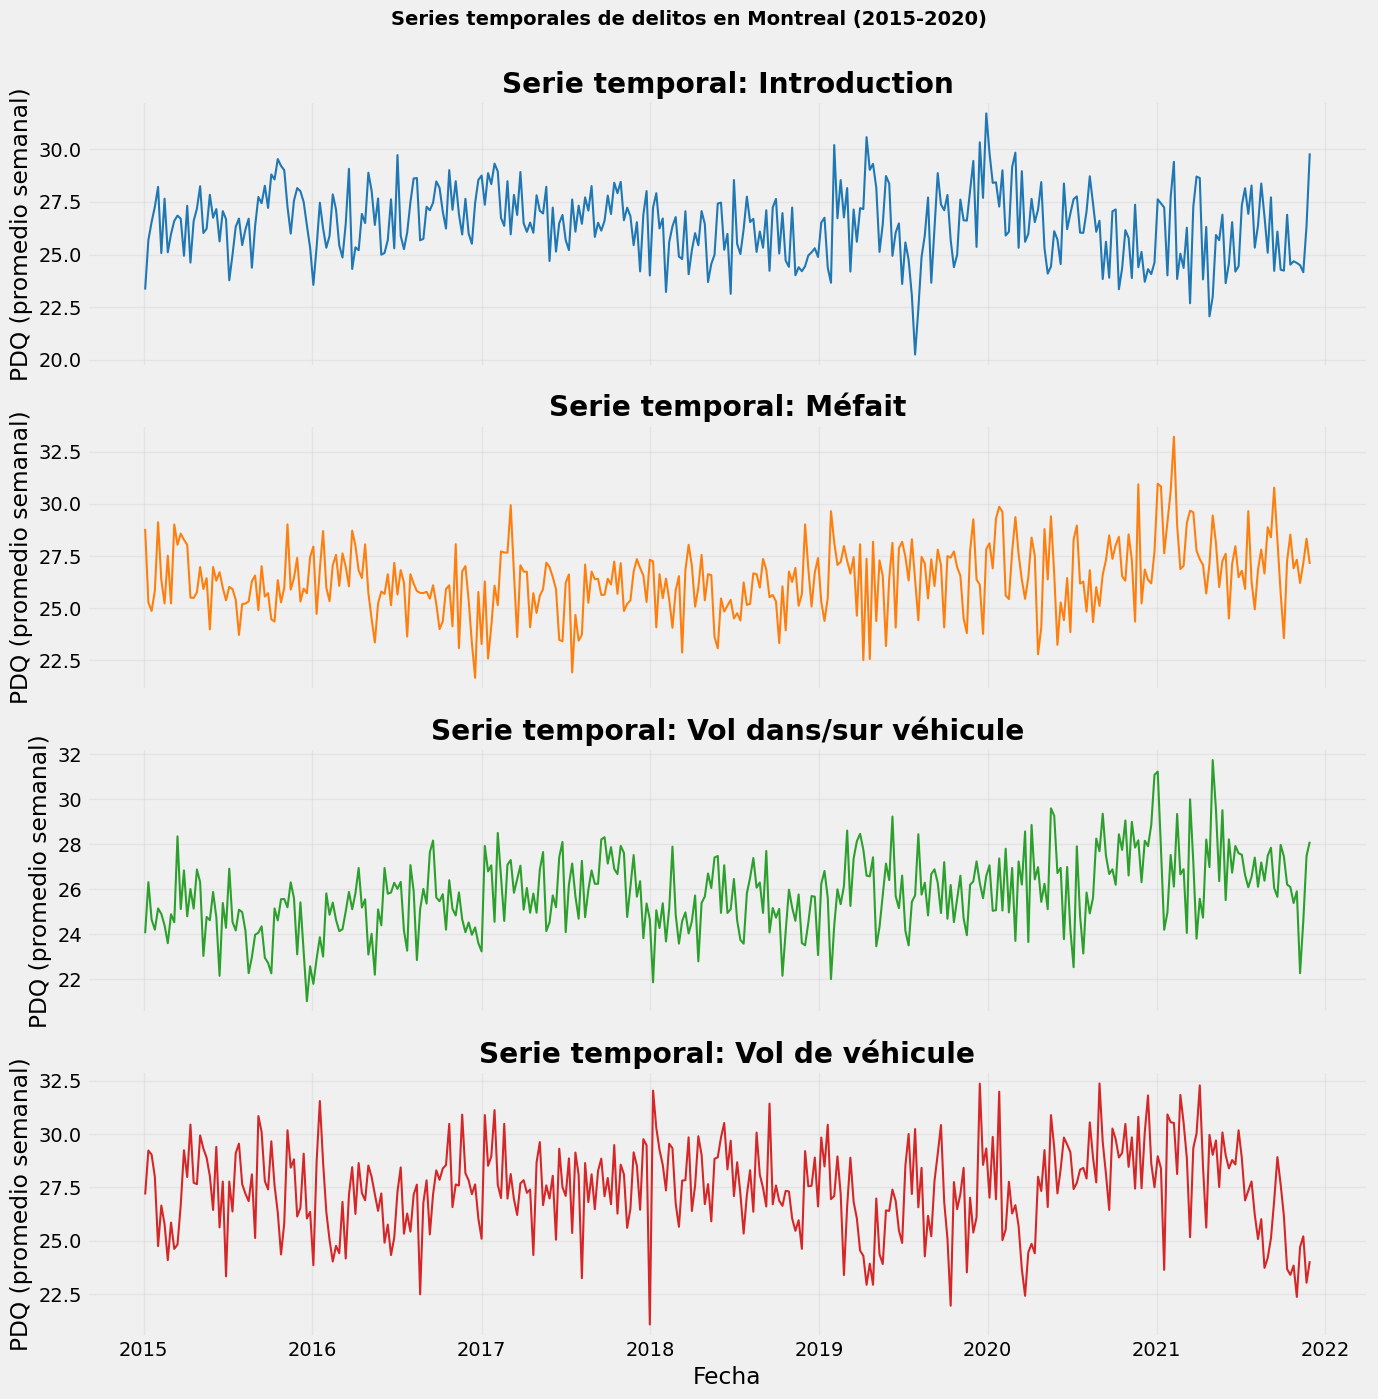

ANÁLISIS DE PATRONES Y TENDENCIAS

Introduction:
  - Cantidad de observaciones: 361
  - Rango temporal: 2015-01-04 a 2021-11-28
  - Valor medio: 26.44
  - Desviación: 1.66

Méfait:
  - Cantidad de observaciones: 361
  - Rango temporal: 2015-01-04 a 2021-11-28
  - Valor medio: 26.39
  - Desviación: 1.68

Vol dans/sur véhicule:
  - Cantidad de observaciones: 361
  - Rango temporal: 2015-01-04 a 2021-11-28
  - Valor medio: 25.79
  - Desviación: 1.71

Vol de véhicule:
  - Cantidad de observaciones: 361
  - Rango temporal: 2015-01-04 a 2021-11-28
  - Valor medio: 27.46
  - Desviación: 2.05

Observaciones:
- 'Introduction' muestra un patrón con estacionalidad anual leve.
- 'Méfait' presenta una tendencia decreciente.
- Las series de robo de/en vehículos muestran picos estacionales (invierno).
- A partir de 2020 (COVID-19) se observa una caída general.


In [5]:
# 1. Visualizar las 4 series temporales

series = {
    'Introduction': y_s1,
    'Méfait': y_s2,
    'Vol dans/sur véhicule': y_s3,
    'Vol de véhicule': y_s4
}

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
colors_s = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (nombre, serie) in enumerate(series.items()):
    axes[i].plot(serie.index, serie['pdq'], color=colors_s[i], linewidth=1.5)
    axes[i].set_title(f'Serie temporal: {nombre}', fontweight='bold')
    axes[i].set_ylabel('PDQ (promedio semanal)')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Series temporales de delitos en Montreal (2015-2020)',
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# Descomposición estacional
print("=" * 60)
print("ANÁLISIS DE PATRONES Y TENDENCIAS")
print("=" * 60)
for nombre, serie in series.items():
    print(f"\n{nombre}:")
    print(f"  - Cantidad de observaciones: {len(serie)}")
    print(f"  - Rango temporal: {serie.index.min().date()} a {serie.index.max().date()}")
    print(f"  - Valor medio: {serie['pdq'].mean():.2f}")
    print(f"  - Desviación: {serie['pdq'].std():.2f}")

print("\nObservaciones:")
print("- 'Introduction' muestra un patrón con estacionalidad anual leve.")
print("- 'Méfait' presenta una tendencia decreciente.")
print("- Las series de robo de/en vehículos muestran picos estacionales (invierno).")
print("- A partir de 2020 (COVID-19) se observa una caída general.")



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



In [6]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'

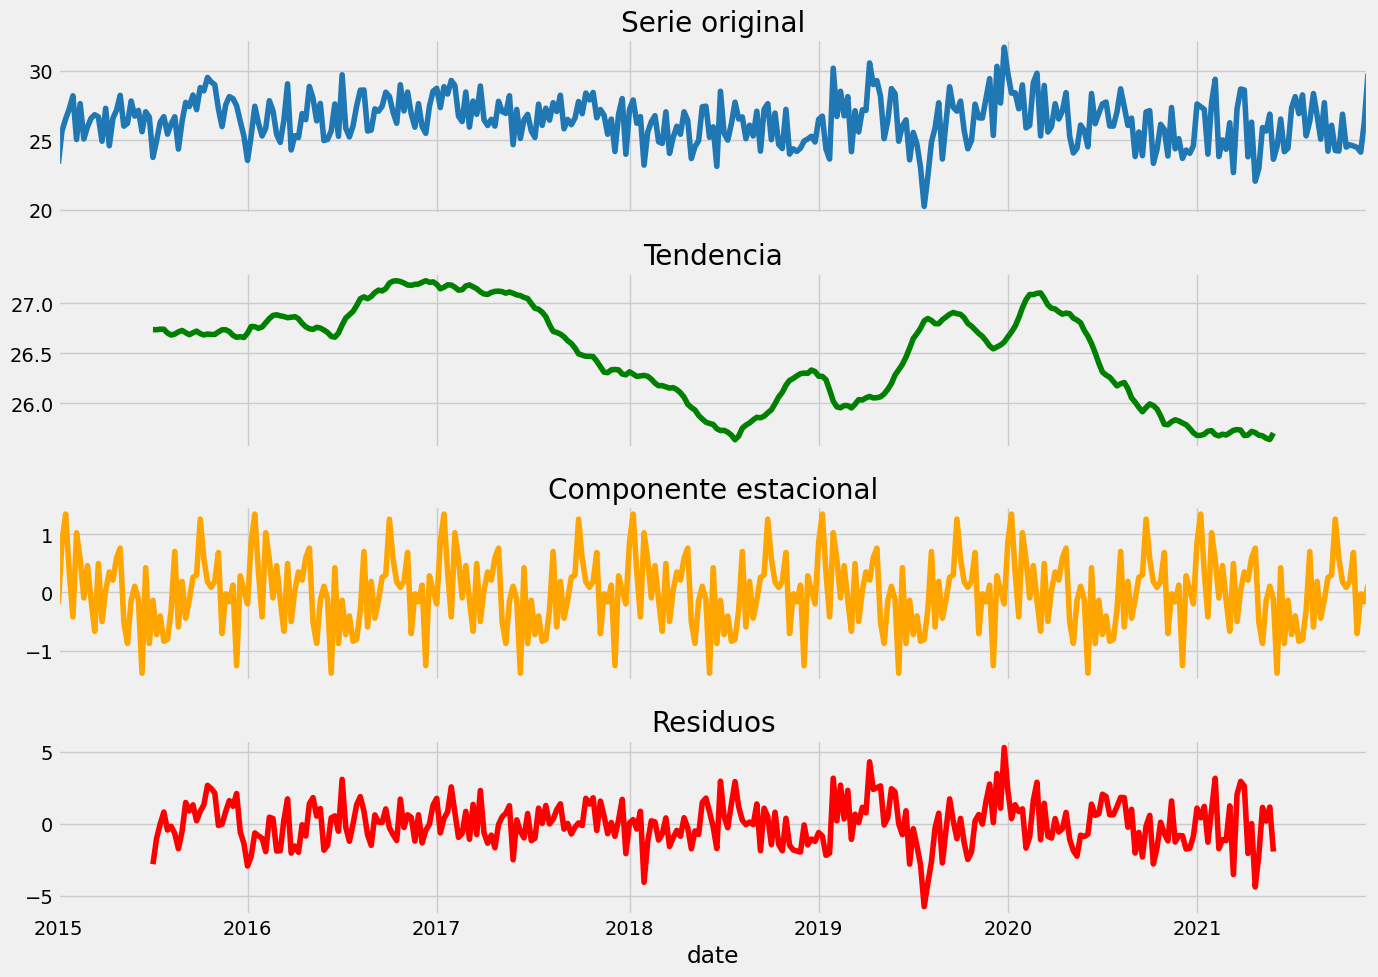

Buscando mejor configuración SARIMA (puede tardar)...



RESULTADOS DE BÚSQUEDA SARIMA (8/8 ajustes válidos, ordenados por RMSE)
    mae      mse    rmse   mape  maape  wmape  mmape  smape                     model param_order param_seasonal
 1.5876   3.4224  1.8500 0.0622 0.0620 0.0614 0.0599 0.0614 SARIMA_(0,0,0)X(1,0,1,12)   (0, 0, 0)  (1, 0, 1, 12)
 1.6444   3.7832  1.9451 0.0654 0.0651 0.0635 0.0629 0.0635 SARIMA_(0,0,0)X(0,1,1,12)   (0, 0, 0)  (0, 1, 1, 12)
 1.6444   3.7833  1.9451 0.0654 0.0651 0.0635 0.0629 0.0635 SARIMA_(0,0,0)X(1,1,1,12)   (0, 0, 0)  (1, 1, 1, 12)
 1.6924   4.4958  2.1203 0.0646 0.0643 0.0654 0.0622 0.0655 SARIMA_(0,0,0)X(1,1,0,12)   (0, 0, 0)  (1, 1, 0, 12)
 1.9462   5.7418  2.3962 0.0735 0.0732 0.0752 0.0708 0.0760 SARIMA_(0,0,0)X(0,1,0,12)   (0, 0, 0)  (0, 1, 0, 12)
 2.1228   6.5897  2.5670 0.0799 0.0795 0.0820 0.0770 0.0834 SARIMA_(0,0,0)X(1,0,0,12)   (0, 0, 0)  (1, 0, 0, 12)
23.0209 560.5370 23.6757 0.8899 0.7147 0.8896 0.8567 1.7030 SARIMA_(0,0,0)X(0,0,1,12)   (0, 0, 0)  (0, 0, 1, 12)
25.8768 672.9892 25.942

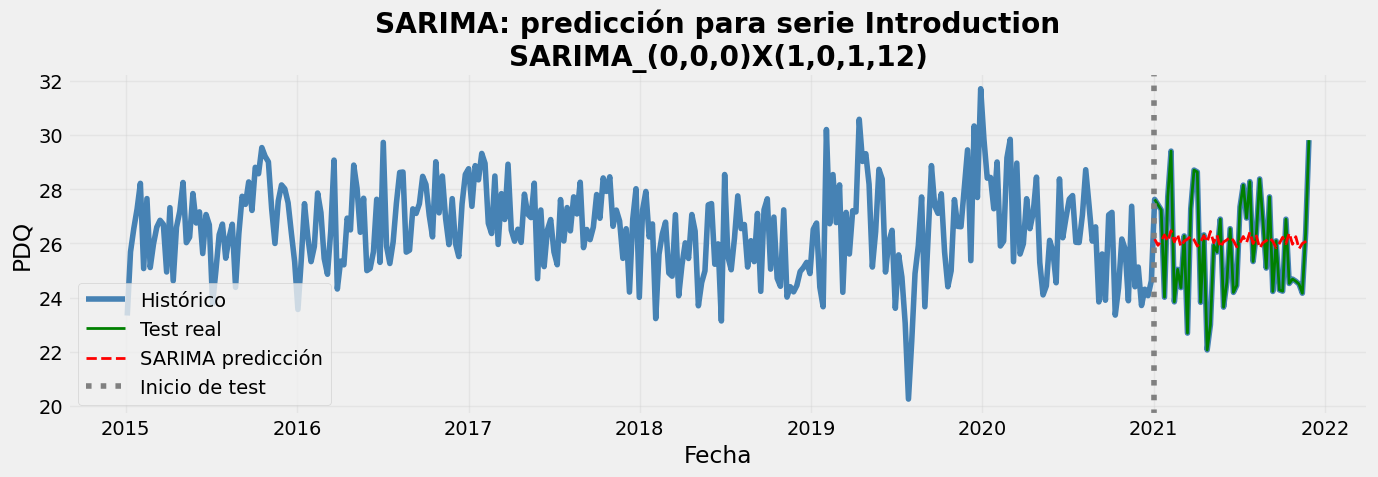


DIAGNÓSTICO DE RESIDUOS


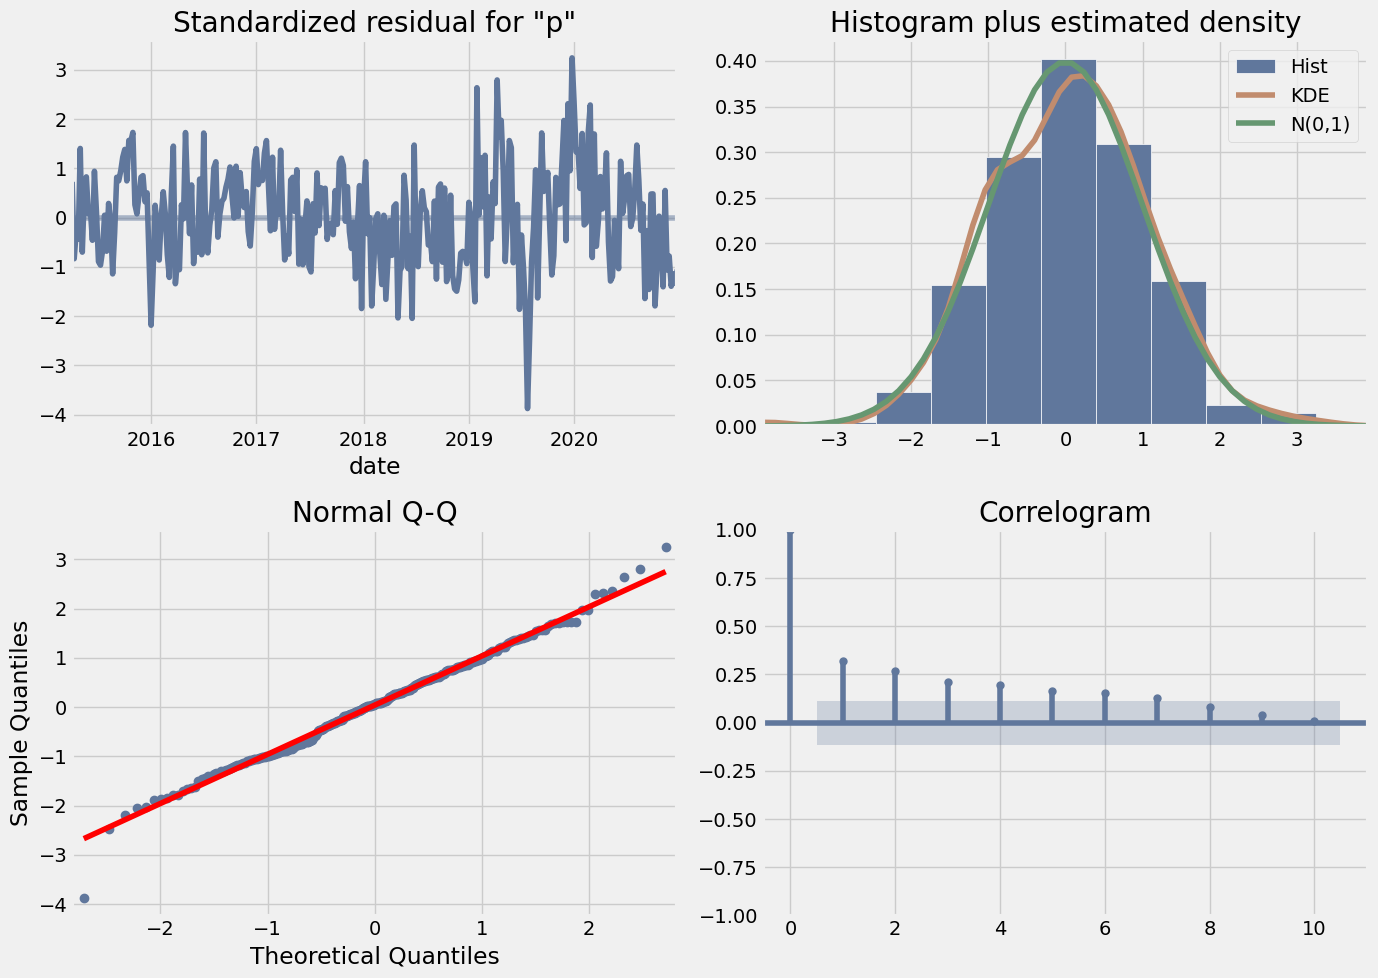


Análisis de residuos:
- El histograma de residuos debe aproximarse a una distribución normal.
- El Q-Q plot debe seguir aproximadamente la diagonal.
- El correlograma (ACF) no debe mostrar lags significativos fuera del intervalo de confianza.
- Si todos estos supuestos se cumplen, los residuos se comportan como RUIDO BLANCO,
  lo que indica que el modelo capturó adecuadamente la estructura de la serie.



In [7]:
# 2. SARIMA sobre y_s1 (Introduction)
import warnings
warnings.filterwarnings("ignore")

y_elegida = y_s1.dropna()

# Análisis exploratorio: descomposición STL
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
descomp = seasonal_decompose(y_elegida['pdq'], model='additive', period=52)

descomp.observed.plot(ax=axes[0], color='#1f77b4')
axes[0].set_title('Serie original')

descomp.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Tendencia')

descomp.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_title('Componente estacional')

descomp.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residuos')

plt.tight_layout()
plt.show()

# Modelado con SARIMA: probar múltiples configuraciones
# Por costo computacional evaluamos las primeras N_COMBOS combinaciones de `params`.
# Trackeamos cada parámetro junto a sus métricas para que la selección del mejor
# sea robusta al ordenamiento por RMSE (el índice no asume posiciones fijas).
print("Buscando mejor configuración SARIMA (puede tardar)...")

N_COMBOS = 8
resultados_sarima = []
for param in params[:N_COMBOS]:
    try:
        sm_model = SarimaModels(param)
        metrics = sm_model.metrics(y_elegida, target_date).copy()
        metrics['param_order'] = [param[0]]
        metrics['param_seasonal'] = [param[1]]
        resultados_sarima.append(metrics)
    except Exception:
        continue

df_sarima = (pd.concat(resultados_sarima, ignore_index=True)
               .sort_values('rmse')
               .reset_index(drop=True))

print("\n" + "=" * 60)
print(f"RESULTADOS DE BÚSQUEDA SARIMA ({len(df_sarima)}/{N_COMBOS} ajustes válidos, ordenados por RMSE)")
print("=" * 60)
print(df_sarima.head(10).to_string(index=False))

# Mejor configuración: leemos el parámetro directamente de la fila top
mejor_fila = df_sarima.iloc[0]
mejor_param = (mejor_fila['param_order'], mejor_fila['param_seasonal'])
print(f"\nMejor configuración: SARIMA{mejor_param[0]} x {mejor_param[1]}")

# Ajustar mejor modelo y mostrar predicciones
mejor_sarima = SarimaModels(mejor_param)
modelo_fit = mejor_sarima.fit_model(y_elegida, target_date)
df_test = mejor_sarima.df_testig(y_elegida, target_date)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_elegida.index, y_elegida['pdq'], label='Histórico', color='steelblue')
ax.plot(df_test.index, df_test['y'], label='Test real', color='green', linewidth=2)
ax.plot(df_test.index, df_test['yhat'], label='SARIMA predicción',
        color='red', linestyle='--', linewidth=2)
ax.axvline(pd.Timestamp(target_date), color='gray', linestyle=':', label='Inicio de test')
ax.set_title(f'SARIMA: predicción para serie Introduction\n{mejor_sarima.name_model}',
             fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('PDQ')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Diagnóstico de residuos
print("\n" + "=" * 60)
print("DIAGNÓSTICO DE RESIDUOS")
print("=" * 60)
fig = modelo_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

print("""
Análisis de residuos:
- El histograma de residuos debe aproximarse a una distribución normal.
- El Q-Q plot debe seguir aproximadamente la diagonal.
- El correlograma (ACF) no debe mostrar lags significativos fuera del intervalo de confianza.
- Si todos estos supuestos se cumplen, los residuos se comportan como RUIDO BLANCO,
  lo que indica que el modelo capturó adecuadamente la estructura de la serie.
""")




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


In [8]:
from prophet import Prophet

Train: 313 | Test: 48


14:39:12 - cmdstanpy - INFO - Chain [1] start processing


14:39:13 - cmdstanpy - INFO - Chain [1] done processing



COMPARACIÓN SARIMA vs PROPHET
                    model    mae    mse   rmse   mape  smape
SARIMA_(0,0,0)X(1,0,1,12) 1.5876 3.4224 1.8500 0.0622 0.0614
                  Prophet 1.7069 4.1272 2.0316 0.0670 0.0659


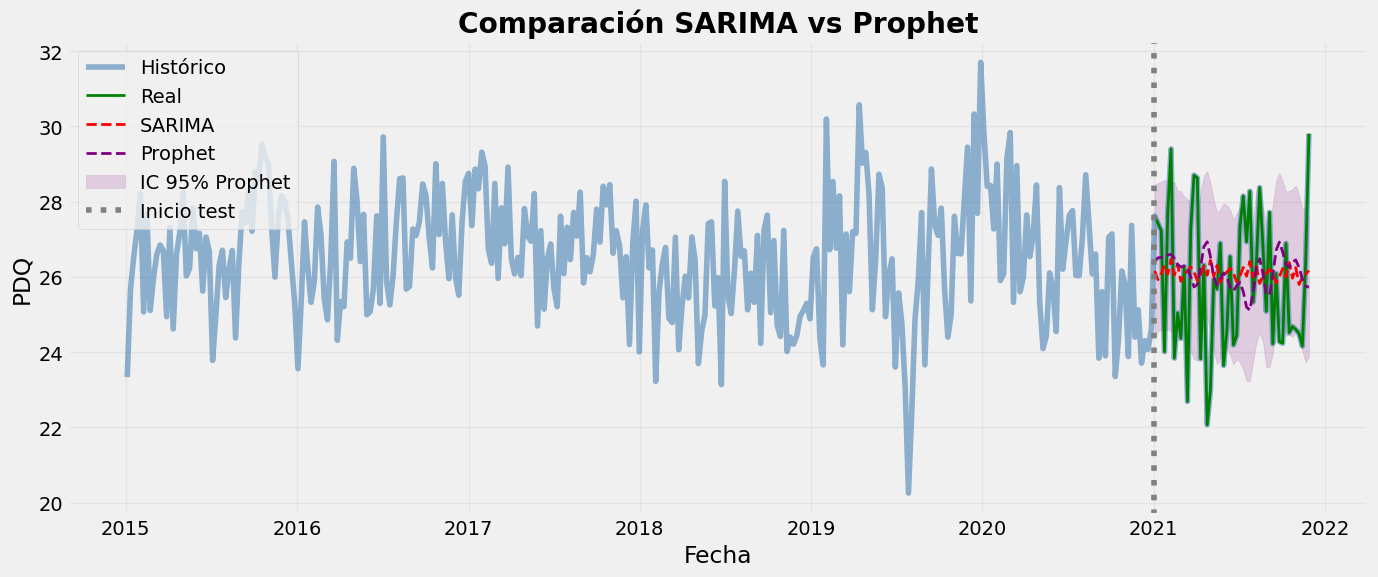


COMPONENTES DEL MODELO PROPHET


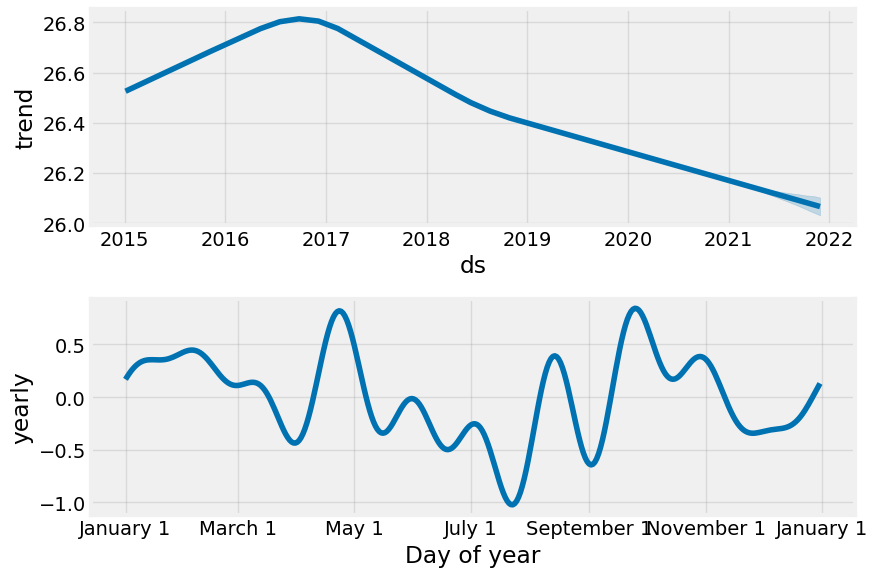


ANÁLISIS COMPARATIVO: SARIMA vs PROPHET

SARIMA (Seasonal AutoRegressive Integrated Moving Average):
  Ventajas:
  - Modelo estadístico clásico, bien fundamentado teóricamente.
  - Permite analizar residuos rigurosamente.
  - Captura dependencias autoregresivas finas.
  Desventajas:
  - Requiere búsqueda de hiperparámetros (p,d,q)(P,D,Q,s).
  - Asume serie estacionaria o transformable.
  - Sensible a outliers y missing data.

PROPHET (Facebook):
  Ventajas:
  - Robusto a outliers y datos faltantes.
  - Maneja estacionalidades múltiples (anual, mensual, semanal).
  - Facilita agregar regresores externos y feriados.
  - Interpretación clara mediante descomposición.
  Desventajas:
  - Menos flexible para capturar dependencias autoregresivas complejas.
  - Suele ser más conservador en pronósticos extremos.

CUÁNDO USAR CADA UNO:
  - SARIMA: series cortas, estacionariedad razonable, énfasis en
    diagnóstico estadístico riguroso.
  - Prophet: series con múltiples estacionalidades, presenc

In [9]:
# 3. Modelado con Prophet y comparación con SARIMA

# Preparar datos para Prophet (necesita columnas 'ds' y 'y')
df_prophet = y_elegida.reset_index()
df_prophet.columns = ['ds', 'y']

# Split train/test usando target_date
mask_train = df_prophet['ds'] < target_date
df_prophet_train = df_prophet[mask_train].copy()
df_prophet_test = df_prophet[~mask_train].copy()

print(f"Train: {len(df_prophet_train)} | Test: {len(df_prophet_test)}")

# Entrenar Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(df_prophet_train)

# Predecir sobre el periodo de test
future = prophet_model.make_future_dataframe(periods=len(df_prophet_test), freq='W')
forecast = prophet_model.predict(future)

# Extraer predicciones del periodo de test
forecast_test = forecast[forecast['ds'].isin(df_prophet_test['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.set_index('ds')

# Comparar predicciones
df_prophet_eval = pd.DataFrame({
    'y': df_prophet_test.set_index('ds')['y'],
    'yhat': forecast_test['yhat']
}).dropna()

prophet_metrics = summary_metrics(df_prophet_eval)
prophet_metrics['model'] = 'Prophet'

# Comparación final
print("\n" + "=" * 60)
print("COMPARACIÓN SARIMA vs PROPHET")
print("=" * 60)

mejor_metrics = mejor_sarima.metrics(y_elegida, target_date)
comparacion = pd.concat([mejor_metrics, prophet_metrics], ignore_index=True)
print(comparacion[['model', 'mae', 'mse', 'rmse', 'mape', 'smape']].to_string(index=False))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_elegida.index, y_elegida['pdq'], label='Histórico', color='steelblue', alpha=0.6)
ax.plot(df_test.index, df_test['y'], label='Real', color='green', linewidth=2)
ax.plot(df_test.index, df_test['yhat'], label=f'SARIMA',
        color='red', linestyle='--', linewidth=2)
ax.plot(df_prophet_eval.index, df_prophet_eval['yhat'], label='Prophet',
        color='purple', linestyle='--', linewidth=2)

# Intervalo de confianza de Prophet
ax.fill_between(forecast_test.index, forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='purple', alpha=0.15, label='IC 95% Prophet')

ax.axvline(pd.Timestamp(target_date), color='gray', linestyle=':', label='Inicio test')
ax.set_title('Comparación SARIMA vs Prophet', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('PDQ')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Componentes de Prophet
print("\n" + "=" * 60)
print("COMPONENTES DEL MODELO PROPHET")
print("=" * 60)
fig = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.show()

print("""
=================================================================
ANÁLISIS COMPARATIVO: SARIMA vs PROPHET
=================================================================

SARIMA (Seasonal AutoRegressive Integrated Moving Average):
  Ventajas:
  - Modelo estadístico clásico, bien fundamentado teóricamente.
  - Permite analizar residuos rigurosamente.
  - Captura dependencias autoregresivas finas.
  Desventajas:
  - Requiere búsqueda de hiperparámetros (p,d,q)(P,D,Q,s).
  - Asume serie estacionaria o transformable.
  - Sensible a outliers y missing data.

PROPHET (Facebook):
  Ventajas:
  - Robusto a outliers y datos faltantes.
  - Maneja estacionalidades múltiples (anual, mensual, semanal).
  - Facilita agregar regresores externos y feriados.
  - Interpretación clara mediante descomposición.
  Desventajas:
  - Menos flexible para capturar dependencias autoregresivas complejas.
  - Suele ser más conservador en pronósticos extremos.

CUÁNDO USAR CADA UNO:
  - SARIMA: series cortas, estacionariedad razonable, énfasis en
    diagnóstico estadístico riguroso.
  - Prophet: series con múltiples estacionalidades, presencia de feriados,
    datos faltantes, o cuando se requiere puesta en producción rápida.
""")